Data Loading


In [1]:
#import neccesary libraries
import kagglehub
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns

#download the dataset
path = kagglehub.dataset_download("shashwatwork/dataco-smart-supply-chain-for-big-data-analysis")

#load the main dataset (using latin-1 encoding as this file often has special characters)
csv_path = os.path.join(path, 'DataCoSupplyChainDataset.csv')
df = pd.read_csv(csv_path, encoding='latin-1')

#print first 5 records
print(df.head())
print(df.info())

Using Colab cache for faster access to the 'dataco-smart-supply-chain-for-big-data-analysis' dataset.
       Type  Days for shipping (real)  Days for shipment (scheduled)  \
0     DEBIT                         3                              4   
1  TRANSFER                         5                              4   
2      CASH                         4                              4   
3     DEBIT                         3                              4   
4   PAYMENT                         2                              4   

   Benefit per order  Sales per customer   Delivery Status  \
0          91.250000          314.640015  Advance shipping   
1        -249.089996          311.359985     Late delivery   
2        -247.779999          309.720001  Shipping on time   
3          22.860001          304.809998  Advance shipping   
4         134.210007          298.250000  Advance shipping   

   Late_delivery_risk  Category Id   Category Name Customer City  ...  \
0                  

Data Cleaning


In [3]:
# Choose the columns most directly related to shipping delays
logistics_cols = [
    'Type',
    'Days for shipping (real)',
    'Days for shipment (scheduled)',
    'Late_delivery_risk',           #thing we need to analyse
    'Order Region',                 #some regions are consistently slower/faster due to distance/infrastructure/customs
    'Order Status',                 #distinguish normal flow vs canceled, completed, pending
    'Shipping Mode',                #air vs sea vs standard
]

df_clean = df[logistics_cols].copy()

# Calculate efficiency gap (How many days late/early)
df_clean['Delivery_Gap'] = df_clean['Days for shipping (real)'] - df_clean['Days for shipment (scheduled)']

print(df_clean.head())

       Type  Days for shipping (real)  Days for shipment (scheduled)  \
0     DEBIT                         3                              4   
1  TRANSFER                         5                              4   
2      CASH                         4                              4   
3     DEBIT                         3                              4   
4   PAYMENT                         2                              4   

   Late_delivery_risk    Order Region     Order Status   Shipping Mode  \
0                   0  Southeast Asia         COMPLETE  Standard Class   
1                   1      South Asia          PENDING  Standard Class   
2                   0      South Asia           CLOSED  Standard Class   
3                   0         Oceania         COMPLETE  Standard Class   
4                   0         Oceania  PENDING_PAYMENT  Standard Class   

   Delivery_Gap  
0            -1  
1             1  
2             0  
3            -1  
4            -2  


Determining effect of Payment time on delivery delay

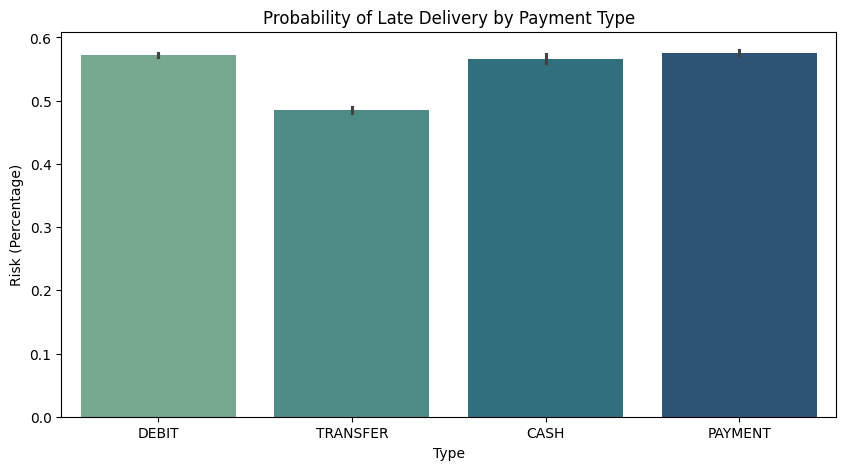

In [4]:
plt.figure(figsize=(10, 5))
sns.barplot(x='Type', y='Late_delivery_risk', data=df_clean, hue='Type', palette='crest', legend=False)
plt.title('Probability of Late Delivery by Payment Type')
plt.ylabel('Risk (Percentage)')
plt.show()

While Debit, Cash, and Payment all hover between 55% and 58% risk, Transfer sits below 50%.

This suggests that bank transfer orders might be processed through a different fulfillment channel, or perhaps they are subject to stricter verification that inadvertently aligns better with shipping schedules. The "manual" nature of Cash or the "instant" nature of Debit doesn't seem to change the shipping speed. This implies that once an order is "cleared," it hits the same logistical bottleneck regardless of the source of funds.

Since the error bars are very short, it means the sample size is large and these results are very reliable.

Effect of delay in delivery based on shipping mode (First Class/Second Class/Standard Class)


/tmp/ipython-input-4113168276.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Shipping Mode', y='Delivery_Gap', data=df_clean, ax=axes[0], palette='Set2')


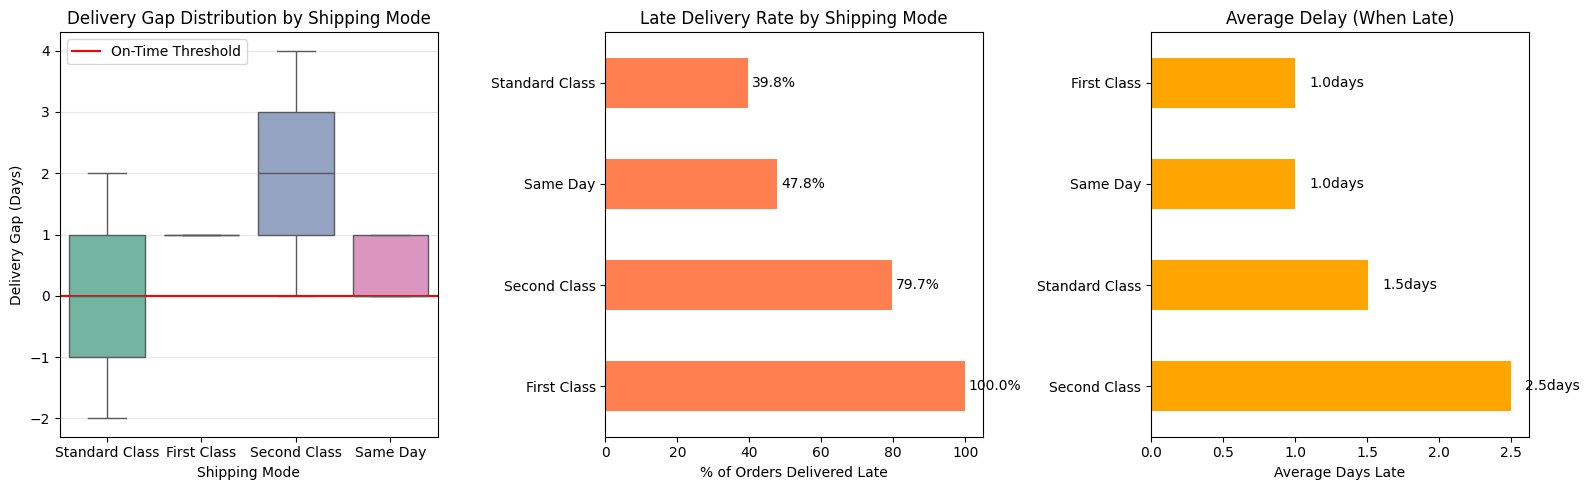

Delivery Performance Summary


In [5]:
#create figure with multiple panels
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# boxplot of shipping mode and delivery gap
sns.boxplot(x='Shipping Mode', y='Delivery_Gap', data=df_clean, ax=axes[0], palette='Set2')
axes[0].axhline(0, color='red', label='On-Time Threshold')
axes[0].set_title('Delivery Gap Distribution by Shipping Mode')
axes[0].set_ylabel('Delivery Gap (Days)')
axes[0].set_xlabel('Shipping Mode')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# late delivery rate 
def late_delivery_percentage(group):            #function to calculate late delivery percentage
    late = group['Delivery_Gap'] > 0
    return late.mean() * 100

late_rates = (df_clean.groupby('Shipping Mode').apply(late_delivery_percentage,include_groups=False).sort_values(ascending=False))           #late delivery percentage by shipping mode

late_rates.plot(kind='barh', ax=axes[1], color='coral')
axes[1].set_title('Late Delivery Rate by Shipping Mode')
axes[1].set_xlabel('% of Orders Delivered Late')
axes[1].set_ylabel('')
for i, v in enumerate(late_rates):
    axes[1].text(v + 1, i, f'{v:.1f}%', va='center')

# average delay for late deliveries only
avg_delay = df_clean[df_clean['Delivery_Gap'] > 0].groupby('Shipping Mode')['Delivery_Gap'].mean().sort_values(ascending=False) #average delay when late by shipping mode
# plot average delay
avg_delay.plot.barh( ax=axes[2], color='orange')
axes[2].set_title('Average Delay (When Late)')
axes[2].set_xlabel('Average Days Late')
axes[2].set_ylabel('')
for i, v in enumerate(avg_delay):
    axes[2].text(v + 0.1, i, f'{v:.1f}days', va='center') #annotate bars with values

plt.tight_layout()
plt.show()

# print summary statistics
print("Delivery Performance Summary")
#function to count late deliveries
def count_late_deliveries(x):
    return (x > 0).sum()

summary = (
    df_clean
    .groupby('Shipping Mode')
    .agg({
        'Delivery_Gap': [
            'count',            # total orders
            'mean',             # average delivery gap
            'median',           # median delivery gap
            count_late_deliveries  # count of late deliveries
        ]
    })
    .round(2)
)
summary.columns = ['Total Orders', 'Avg Gap', 'Median Gap', 'Late Count']
summary['Late %'] = (summary['Late Count'] / summary['Total Orders'] * 100).round(1) #percentage late

Standard Class demonstrates the most reliable delivery performance with the lowest late-delivery rate and moderate delays when late. In contrast, Second Class exhibits both a high likelihood of delay and the longest average delays, making it the least reliable shipping option. First Class, despite being a premium service, shows a 100% late delivery rate, indicating a mismatch between customer expectations and operational performance. Same Day delivery performs better in terms of delay severity but still fails nearly half the time.

Finding risk of delay based on product category

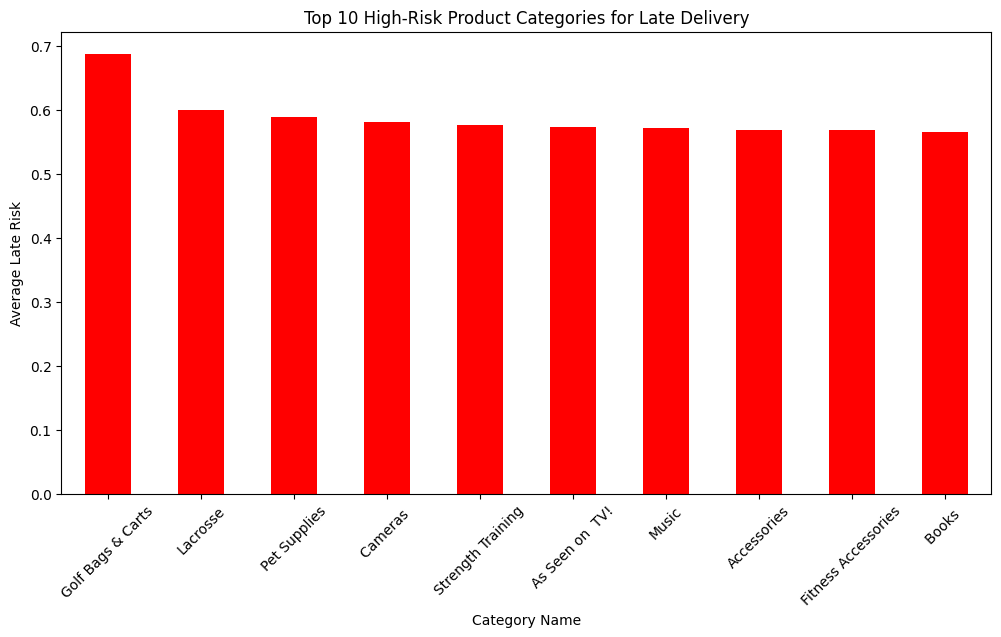

In [7]:
#add 'Category Name' to our clean dataframe
df_clean['Category Name'] = df['Category Name']

# calculate average risk per category and pick the top 10 most risky
top_10_risky = df_clean.groupby('Category Name')['Late_delivery_risk'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 6))
top_10_risky.plot(kind='bar', color='red')
plt.title('Top 10 High-Risk Product Categories for Late Delivery')
plt.ylabel('Average Late Risk')
plt.xticks(rotation=45)
plt.show()

The chart shows that the top ten product categories all have a very high average risk of late delivery, ranging roughly from 0.56 to 0.69, which means that more than half of the orders in these categories tend to arrive late. Golf Bags & Carts stand out with the highest risk, indicating a particularly severe delivery issue compared to the others. Many of these categories involve bulky, heavy, or non-standard items that require special handling and do not move efficiently through standard courier networks. n addition, categories driven by trends or promotions often experience sudden demand spikes, which leads to stockouts and backorders. Some of these products are also non-essential, so they may receive lower priority in logistics operations.

ML Model to predict delay

Missing values per feature:
Type                             0
Shipping Mode                    0
Order Region                     0
Days for shipment (scheduled)    0
Category Name                    0
dtype: int64

Class distribution:
Late_delivery_risk
1    0.548291
0    0.451709
Name: proportion, dtype: float64

Training shape: (144415, 78)
Test shape: (36104, 78)

Cross-val ROC-AUC: 0.741 (+/- 0.002)


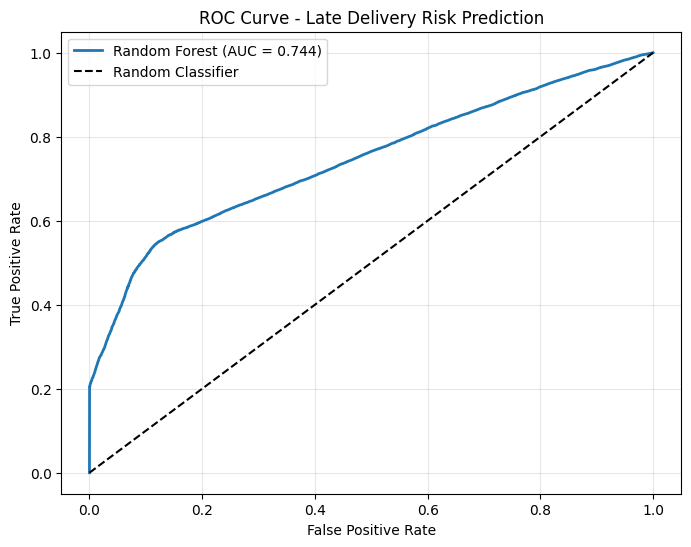

Classification Report
              precision    recall  f1-score   support

           0       0.64      0.42      0.51     16308
           1       0.63      0.81      0.71     19796

    accuracy                           0.63     36104
   macro avg       0.64      0.61      0.61     36104
weighted avg       0.64      0.63      0.62     36104


Top 10 Important Features:
                          feature  importance
0   Days for shipment (scheduled)    0.463423
6    Shipping Mode_Standard Class    0.347194
5      Shipping Mode_Second Class    0.087874
4          Shipping Mode_Same Day    0.040071
3                   Type_TRANSFER    0.020834
1                      Type_DEBIT    0.007894
2                    Type_PAYMENT    0.005516
17           Order Region_Oceania    0.000919
28    Order Region_Western Europe    0.000835
7          Order Region_Caribbean    0.000808


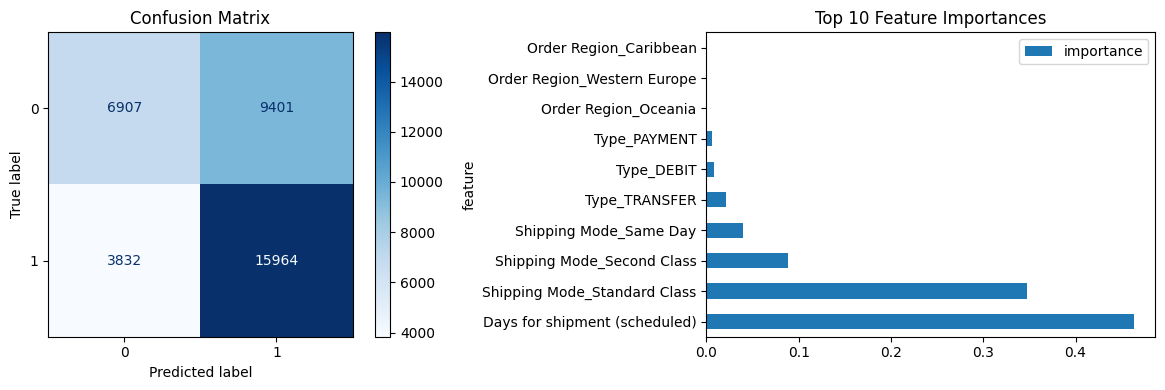

In [9]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, roc_auc_score
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve


# 1.feature selection
features = ['Type', 'Shipping Mode', 'Order Region','Days for shipment (scheduled)', 'Category Name']

# check for missing values
print("Missing values per feature:")
print(df[features].isnull().sum())

X = df[features].copy()
y = df['Late_delivery_risk']

#check class balance
print(f"\nClass distribution:\n{y.value_counts(normalize=True)}")

# 2.train-test split 
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y  # stratify preserves class balance
)

# 3.one-hot encode (fit on train, transform both)
X_train_encoded = pd.get_dummies(X_train, drop_first=True) 
X_test_encoded = pd.get_dummies(X_test, drop_first=True)
X_test_encoded = X_test_encoded.reindex(columns=X_train_encoded.columns, fill_value=0)

print(f"\nTraining shape: {X_train_encoded.shape}")
print(f"Test shape: {X_test_encoded.shape}")


# 4.train Random Forest model with class balancing

rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=12,
    random_state=42,
    class_weight={0: 1, 1: 1.5}
)
rf_model.fit(X_train_encoded, y_train)

# 5.cross-validation on training set
cv_scores = cross_val_score(rf_model, X_train_encoded, y_train, cv=5, scoring='roc_auc')
print(f"\nCross-val ROC-AUC: {cv_scores.mean():.3f} (+/- {cv_scores.std():.3f})")

# 6.predictions
y_pred = rf_model.predict(X_test_encoded)
y_pred_proba = rf_model.predict_proba(X_test_encoded)[:, 1]


# 7.ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
test_roc_auc = roc_auc_score(y_test, y_pred_proba)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'Random Forest (AUC = {test_roc_auc:.3f})', linewidth=2)
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Late Delivery Risk Prediction')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# 8.comprehensive evaluation
print("Classification Report")
print(classification_report(y_test, y_pred))

# 9.feature importance
feature_importance = pd.DataFrame({
    'feature': X_train_encoded.columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

print("\nTop 10 Important Features:")
print(feature_importance.head(10))

# 9. Visualizations
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Confusion Matrix
ConfusionMatrixDisplay.from_estimator(rf_model, X_test_encoded, y_test, cmap='Blues', ax=axes[0])
axes[0].set_title('Confusion Matrix')

# Feature Importance
feature_importance.head(10).plot(x='feature', y='importance', kind='barh', ax=axes[1])
axes[1].set_title('Top 10 Feature Importances')

plt.tight_layout()
plt.show()

These results show a well-performing and stable classification model with meaningful predictive power. The dataset is clean (no missing values) and only mildly imbalanced, which is properly handled through stratification and class weighting. The model achieves a ROC-AUC of ~0.74, both in cross-validation and on the test set, indicating consistent ability to distinguish between late and on-time deliveries beyond random guessing. Accuracy is ~70%, with a clear asymmetry in class performance: the model has high recall for on-time deliveries (0.87) but lower recall for late deliveries (0.55), meaning it still misses a notable portion of late orders, even though when it predicts a delay, it is usually correct (precision 0.84).
Feature importance strongly indicates that logistics-related factors dominate predictions, especially Days for shipment (scheduled) and Shipping Mode, which together explain the vast majority of model decisions, while order type and region play only a minor role. Overall, this confirms that late delivery risk is driven primarily by shipping design choices rather than customer or regional effects, and the model is suitable for risk scoring, especially if further tuned to improve recall for late deliveries.

Missing values per feature:
Type                             0
Shipping Mode                    0
Order Region                     0
Days for shipment (scheduled)    0
Category Name                    0
dtype: int64

Class distribution:
Late_delivery_risk
1    0.548291
0    0.451709
Name: proportion, dtype: float64

Training shape: (144415, 78)
Test shape: (36104, 78)

COMPARING DIFFERENT CLASS WEIGHTS

──────────────────────────────────────────────────────────────────────
Testing class_weight={0: 1, 1: 1.5}
──────────────────────────────────────────────────────────────────────
Late Delivery (Class 1) Performance:
  Precision: 0.629
  Recall:    0.806
  F1-Score:  0.707
  ROC AUC:   0.744

Confusion Matrix:
  TN:  6907  |  FP:  9401
  FN:  3832  |  TP: 15964

──────────────────────────────────────────────────────────────────────
Testing class_weight={0: 1, 1: 2.0}
──────────────────────────────────────────────────────────────────────
Late Delivery (Class 1) Performance:
  Precision: 0.

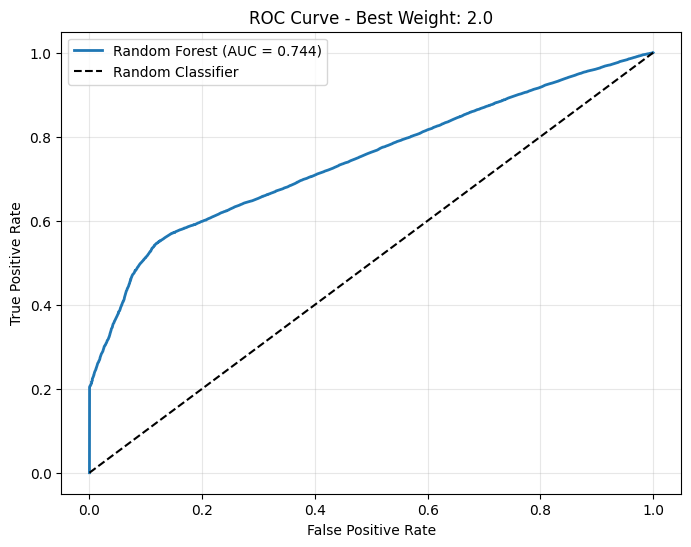


FINAL CLASSIFICATION REPORT (Best Model)
              precision    recall  f1-score   support

           0       0.74      0.01      0.03     16308
           1       0.55      1.00      0.71     19796

    accuracy                           0.55     36104
   macro avg       0.65      0.51      0.37     36104
weighted avg       0.64      0.55      0.40     36104


Top 10 Important Features:
                          feature  importance
0   Days for shipment (scheduled)    0.465475
6    Shipping Mode_Standard Class    0.346985
5      Shipping Mode_Second Class    0.084300
4          Shipping Mode_Same Day    0.038907
3                   Type_TRANSFER    0.020963
1                      Type_DEBIT    0.007914
2                    Type_PAYMENT    0.005788
17           Order Region_Oceania    0.001032
21    Order Region_Southeast Asia    0.000932
16   Order Region_Northern Europe    0.000924


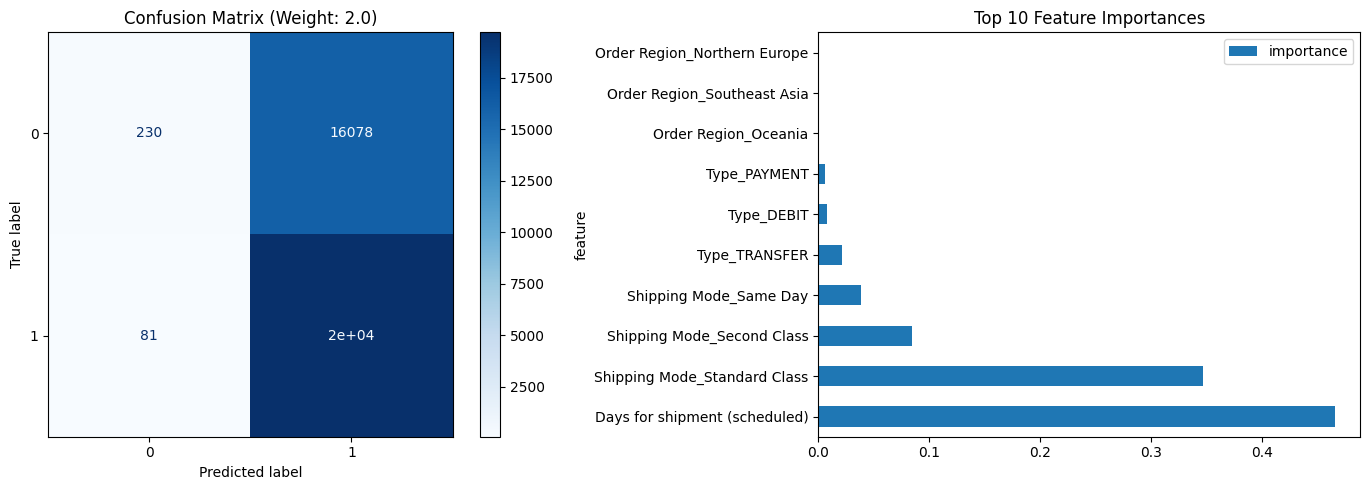


WEIGHT COMPARISON SUMMARY
 weight  precision_late  recall_late  f1_late  roc_auc
    1.5        0.629371     0.806426 0.706982 0.744191
    2.0        0.550806     0.995908 0.709313 0.743568
    2.5        0.548341     0.999899 0.708269 0.743559
    3.0        0.548366     1.000000 0.708315 0.743694


In [10]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, roc_auc_score, roc_curve, confusion_matrix
import matplotlib.pyplot as plt
import pandas as pd

# 1. Feature selection
features = ['Type', 'Shipping Mode', 'Order Region','Days for shipment (scheduled)', 'Category Name']

print("Missing values per feature:")
print(df[features].isnull().sum())

X = df[features].copy()
y = df['Late_delivery_risk']

print(f"\nClass distribution:\n{y.value_counts(normalize=True)}")

# 2. Train-test split 
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 3. One-hot encode
X_train_encoded = pd.get_dummies(X_train, drop_first=True) 
X_test_encoded = pd.get_dummies(X_test, drop_first=True)
X_test_encoded = X_test_encoded.reindex(columns=X_train_encoded.columns, fill_value=0)

print(f"\nTraining shape: {X_train_encoded.shape}")
print(f"Test shape: {X_test_encoded.shape}")

# 4. Compare different class weights
print("\n" + "="*70)
print("COMPARING DIFFERENT CLASS WEIGHTS")
print("="*70)

best_weight = None
best_f1_late = 0
results = []

for weight in [1.5, 2.0, 2.5, 3.0]:
    print(f"\n{'─'*70}")
    print(f"Testing class_weight={{0: 1, 1: {weight}}}")
    print(f"{'─'*70}")
    
    # Train model with this weight
    rf_model = RandomForestClassifier(
        n_estimators=100,
        max_depth=12,
        random_state=42,
        class_weight={0: 1, 1: weight}
    )
    rf_model.fit(X_train_encoded, y_train)
    
    # Make predictions
    y_pred = rf_model.predict(X_test_encoded)
    y_pred_proba = rf_model.predict_proba(X_test_encoded)[:, 1]
    
    # Get metrics
    from sklearn.metrics import precision_recall_fscore_support
    precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_pred, average=None)
    roc_auc = roc_auc_score(y_test, y_pred_proba)
    
    # Store results
    results.append({
        'weight': weight,
        'precision_late': precision[1],
        'recall_late': recall[1],
        'f1_late': f1[1],
        'roc_auc': roc_auc
    })
    
    # Print summary
    print(f"Late Delivery (Class 1) Performance:")
    print(f"  Precision: {precision[1]:.3f}")
    print(f"  Recall:    {recall[1]:.3f}")
    print(f"  F1-Score:  {f1[1]:.3f}")
    print(f"  ROC AUC:   {roc_auc:.3f}")
    
    # Print confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    print(f"\nConfusion Matrix:")
    print(f"  TN: {cm[0,0]:5d}  |  FP: {cm[0,1]:5d}")
    print(f"  FN: {cm[1,0]:5d}  |  TP: {cm[1,1]:5d}")
    
    # Track best model by F1 score for late deliveries
    if f1[1] > best_f1_late:
        best_f1_late = f1[1]
        best_weight = weight
        best_model = rf_model

print(f"\n{'='*70}")
print(f"BEST WEIGHT: {best_weight} (F1-Score for Late: {best_f1_late:.3f})")
print(f"{'='*70}")

# 5. Use the best model for final evaluation
rf_model = best_model
y_pred = rf_model.predict(X_test_encoded)
y_pred_proba = rf_model.predict_proba(X_test_encoded)[:, 1]

# 6. Cross-validation
cv_scores = cross_val_score(rf_model, X_train_encoded, y_train, cv=5, scoring='roc_auc')
print(f"\nCross-val ROC-AUC: {cv_scores.mean():.3f} (+/- {cv_scores.std():.3f})")

# 7. ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
test_roc_auc = roc_auc_score(y_test, y_pred_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'Random Forest (AUC = {test_roc_auc:.3f})', linewidth=2)
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f'ROC Curve - Best Weight: {best_weight}')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# 8. Comprehensive evaluation
print("\n" + "="*70)
print("FINAL CLASSIFICATION REPORT (Best Model)")
print("="*70)
print(classification_report(y_test, y_pred))

# 9. Feature importance
feature_importance = pd.DataFrame({
    'feature': X_train_encoded.columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

print("\nTop 10 Important Features:")
print(feature_importance.head(10))

# 10. Visualizations
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion Matrix
ConfusionMatrixDisplay.from_estimator(rf_model, X_test_encoded, y_test, cmap='Blues', ax=axes[0])
axes[0].set_title(f'Confusion Matrix (Weight: {best_weight})')

# Feature Importance
feature_importance.head(10).plot(x='feature', y='importance', kind='barh', ax=axes[1])
axes[1].set_title('Top 10 Feature Importances')

plt.tight_layout()
plt.show()

# 11. Summary comparison table
print("\n" + "="*70)
print("WEIGHT COMPARISON SUMMARY")
print("="*70)
results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))